In [1]:
## Cell blocks content Overview


#1. Import Packages
#2. Import whisper (not in use)
#3. Download the datasets from the opensanctions website 
#4. Load statement dataset
#5. Check countries
#6. Load entities dataset
#7. Check entities json file
#8. Load names files
#9. Check json data
#10. Load entities json data
#11. Load schema entities data

#12. Function to create synthetic transactions
#13. Define pertubations
#14. Generate 10000 synthetic transactions
#15. Inject labeled sanctioned hits with pertubations
#16. Combine, shuffle and save the sampled data
#17. Save the synthetic transactions data

#18. Load the synthetic transactions data and the sanctioned names and keep only sanctioned names
#19. Normalize the sanctioned names
#20. Build blocking index
#21. create similarity scoring function weighted on 5 methdods.
#22. Run screening pipeline
#23. Run a quick sanity check
#24. Run Model performance and Evaluation

#25. Check metrics on different thresholds
#26. Find the optimal threshold
#27. Run the confusion metrics on the optimal threshold
#28. Run Ranking and Discrimination metrics
#29. Run Operational and Business metrics
#30. Score Distribution analysis 
#31. Plots
#32. Summary Report 


In [ ]:
# Explain all the different files pulled from the open sanctions dataset website



#Justify which datasets are relevant and those that are not and why



# Create a storyline to explain how the model is being designed and the goal of the project. 



In [1]:
# Import packages

from __future__ import annotations
import os
import re
import io
import sys
import json
import random
import unicodedata
import pandas as pd
import numpy as np
import requests
import jellyfish
from rapidfuzz import fuzz, distance
from pathlib import Path
from faker import Faker
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

from rapidfuzz import fuzz
from rapidfuzz.distance import Levenshtein
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings("ignore")

#### import whisper as ws
#model = ws.load_model("base")

In [ ]:
#Downloading the consolidated sanctions data from the open sanctions website. 
# The data consists of sanctioned entities across 268 countries. 


# -----------------------------------
# Base dataset URL
# -----------------------------------
BASE_URL = "https://data.opensanctions.org/datasets/latest/default/"

# -----------------------------------
# Files in dataset
# -----------------------------------
files = [
    "entities.ftm.json",
    "names.txt",
    "senzing.json",
    "statements.csv",
    "targets.nested.json",
    "targets.simple.csv"
]

# -----------------------------------
# Create output folder
# -----------------------------------
os.makedirs("opensanctions_data", exist_ok=True)

downloaded_files = []

# -----------------------------------
# Download each file
# -----------------------------------
for file in files:

    url = BASE_URL + file
    output_path = os.path.join("opensanctions_data", file)

    print(f"Downloading: {file}")

    with requests.get(url, stream=True) as r:
        r.raise_for_status()

        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

    downloaded_files.append(output_path)

print("\nAll files downloaded successfully!")

# -----------------------------------
# Example: Load simplified CSV for analysis
# -----------------------------------


In [2]:
#Load Target data
#csv_path = "opensanctions_data/targets_simple.csv"

#df = pd.read_csv(csv_path)

#print("\nDataset preview:")
#print(df.head())

#print("\nShape:", df.shape)

In [10]:
# Load Statement
#statements_df = pd.read_csv("opensanctions_data/statements.csv")
#statements_df.head()

,canonical_id,entity_id,prop,prop_type,schema,value,dataset,origin,lang,original_value,external,first_seen,last_seen,id
0,NK-2229ydxkHNa5AcDp9d6jt3,wd-e6fbb0b4a5647317a4610efb1f52003ec1bb437e,startDate,date,Occupancy,2015-04-02,wd_peps,NaN,NaN,2015-04-02,f,2026-01-15T03:48:43,2026-05-22T02:57:17,b28a6a5806410e095f34ec856bfc79a153fd428d
1,NK-2229ydxkHNa5AcDp9d6jt3,wd-e6fbb0b4a5647317a4610efb1f52003ec1bb437e,startDate,date,Occupancy,2015-04-02,wd_categories,NaN,NaN,2015-04-02,f,2026-03-16T11:27:08,2026-05-22T00:13:33,8c11147fceb282fe15fc3e2926d58b459eef8b37
2,NK-2229ydxkHNa5AcDp9d6jt3,wd-e6fbb0b4a5647317a4610efb1f52003ec1bb437e,constituency,string,Occupancy,canton of Pessac-2,wd_peps,NaN,eng,Q27057,f,2026-03-06T03:49:58,2026-05-22T02:57:17,805b8661795434bff41268ea0b894dc785f68d50
3,NK-2229ydxkHNa5AcDp9d6jt3,wd-e6fbb0b4a5647317a4610efb1f52003ec1bb437e,constituency,string,Occupancy,canton of Pessac-2,wd_categories,NaN,eng,Q27057,f,2026-03-16T11:27:08,2026-05-22T00:13:33,b2385273d3ce824a2e4300fe174d337be76106f9
4,NK-2229ydxkHNa5AcDp9d6jt3,wd-e6fbb0b4a5647317a4610efb1f52003ec1bb437e,post,entity,Occupancy,Q63758900,wd_categories,NaN,NaN,Q63758900,f,2026-03-16T11:27:08,2026-05-22T00:13:33,c6d28d1834a236486b3b4cf8c32ddadc4867e376


In [ ]:
# Df is the targets data frame. See the big chunk of code. Extract the countries column from there and assess it here
#s = target['countries'].value_counts()
#s.reset_index()
#s.to_csv("countries.csv")

In [2]:
 # Load the Entities data

def load_json_lines(filepath):
    """Load a newline-delimited JSON file into a list of dicts."""
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

In [3]:
entities = load_json_lines("opensanctions_data/entities_ftm.json")

In [4]:
# Load flat name list for quick lookup / blocking
with open("opensanctions_data/names.txt", "r") as f:
    name_list = [line.strip() for line in f if line.strip()]
print(f"{len(name_list):,} name variants loaded")

3,072,792 name variants loaded


load_json_lines("opensanctions_data/senzing.json")
senzing.head()

In [15]:
print(json.dumps(entities[0], indent=2))
entities[0].keys()

{
  "id": "NK-2229ydxkHNa5AcDp9d6jt3",
  "caption": "Occupancy",
  "schema": "Occupancy",
  "referents": [
    "wd-4f78058be60118f60f58a1b7a3a98f37a29b52e7",
    "wd-e6fbb0b4a5647317a4610efb1f52003ec1bb437e",
    "wd-9e8d9b8e4656f484e477fee7758b9ea9e19e4014"
  ],
  "datasets": [
    "wd_categories",
    "wd_peps"
  ],
  "first_seen": "2026-01-15T03:48:43",
  "last_seen": "2026-05-22T02:57:17",
  "last_change": "2026-03-16T11:27:08",
  "properties": {
    "startDate": [
      "2015-04-02"
    ],
    "constituency": [
      "canton of Pessac-2"
    ],
    "post": [
      "Q63758900"
    ],
    "holder": [
      "Q63765953"
    ]
  },
  "target": false
}


dict_keys(['id', 'caption', 'schema', 'referents', 'datasets', 'first_seen', 'last_seen', 'last_change', 'properties', 'target'])

In [4]:
import json
import pandas as pd

records = []

with open("opensanctions_data/entities_ftm.json", "r") as f:
    for line in f:
        entity = json.loads(line)
        schema = entity.get("schema")
        
        # Only keep sanctioned persons and organizations
        if schema not in ["Person", "Organization", "LegalEntity","Company"]:
            continue
        
        # Optional: only keep actual targets
        # if not entity.get("target", False):
        #     continue
        
        props = entity.get("properties", {})
        names = props.get("name", []) + props.get("alias", [])
        
        for name in names:
            records.append({
                "entity_id": entity.get("id"),
                "caption": entity.get("caption"),
                "schema": schema,
                "name": name,
                "country": props.get("nationality", props.get("country", [None]))[0],
                "dob": props.get("birthDate", [None])[0],
                "datasets": ", ".join(entity.get("datasets", [])),
                "is_target": entity.get("target", False)
            })

sanctions_df = pd.DataFrame(records)
print(f"Total name variants: {sanctions_df.shape[0]:,}")
print(f"Unique entities: {sanctions_df['entity_id'].nunique():,}")
print(f"\nSchema breakdown:\n{sanctions_df['schema'].value_counts()}")
print(f"\nTarget breakdown:\n{sanctions_df['is_target'].value_counts()}")

Total name variants: 2,963,126


Unique entities: 1,587,613

Schema breakdown:
schema
Person          2245417
Company          435462
Organization     187353
LegalEntity       94894
Name: count, dtype: int64

Target breakdown:
is_target
True     2495466
False     467660
Name: count, dtype: int64


In [5]:
schemas = []
with open("opensanctions_data/entities_ftm.json", "r") as f:
    for line in f:
        entity = json.loads(line)
        schemas.append(entity.get("schema"))

pd.Series(schemas).value_counts()

Person            1162699
Occupancy          899548
Sanction           615107
Security           373121
Company            239766
Ownership          237681
Position           174187
Directorship       140617
Organization       101595
LegalEntity         84273
Family              74381
UnknownLink         43803
Succession          37296
Address             30266
CryptoWallet        13688
Documentation       13496
Passport            11293
Vessel               9838
Identification       5580
Article              3475
Representation       2960
Associate            2613
Membership           2060
Employment           1545
Airplane              344
PublicBody            198
Asset                  35
Payment                22
Debt                    2
Name: count, dtype: int64

In [6]:
# ============================================================
# Chunk 2 — Synthetic Transaction Generation
# ============================================================

fake = Faker()
random.seed(42)
np.random.seed(42)

# ============================================================
# STEP 1 — Load sanctions names (output from code cell above)
# ============================================================

#sanctions_df = pd.read_csv("sanctions_entities.csv")  # saved from Notebook 1

# Pull only actual targets with names
target_names = (
    sanctions_df[sanctions_df["is_target"] == True]["name"]
    .dropna()
    .unique()
    .tolist()
)

print(f"Sanctions target name variants available: {len(target_names):,}")

Sanctions target name variants available: 2,350,845


In [7]:
# ============================================================
# STEP 2 — Define perturbation functions (realistic noise)
# ============================================================

def insert_typo(name):
    """Randomly swap or drop a character"""
    if len(name) < 4:
        return name
    i = random.randint(1, len(name) - 2)
    return name[:i] + random.choice("aeiou") + name[i+1:]

def reorder_tokens(name):
    """Swap first and last name"""
    tokens = name.split()
    if len(tokens) >= 2:
        random.shuffle(tokens)
    return " ".join(tokens)

def drop_token(name):
    """Remove a middle name or token"""
    tokens = name.split()
    if len(tokens) > 2:
        tokens.pop(random.randint(1, len(tokens) - 2))
    return " ".join(tokens)

def transliterate(name):
    """Common transliteration swaps"""
    swaps = {
        "MOHAMMED": "MUHAMMAD", "MUHAMMAD": "MOHAMMAD",
        "AHMAD": "AHMED", "AHMED": "AHMAD",
        "ALI": "ALLI", "HASSAN": "HASAN",
        "JOSEPH": "JOSEF", "IVAN": "IVAN"
    }
    for k, v in swaps.items():
        if k in name.upper():
            return name.upper().replace(k, v)
    return name

def add_prefix(name):
    """Add title/honorific"""
    prefixes = ["Mr ", "Dr ", "Sheikh ", "Al-", "Al "]
    return random.choice(prefixes) + name

def perturb(name):
    """Apply 1-2 random perturbations"""
    fns = [insert_typo, reorder_tokens, drop_token, transliterate, add_prefix]
    chosen = random.sample(fns, k=random.randint(1, 2))
    for fn in chosen:
        name = fn(name)
    return name

In [8]:
# ============================================================
# STEP 3 — Generate 10,000 clean synthetic transactions
# ============================================================

n_transactions = 10_000
n_hits = 200  # inject 200 labeled sanctions hits

transactions = []

for i in range(n_transactions - n_hits):
    transactions.append({
        "txn_id": f"TXN-{i:05d}",
        "name": fake.name().upper(),
        "country": fake.country_code(),
        "amount": round(random.uniform(100, 500_000), 2),
        "currency": random.choice(["USD", "EUR", "GBP", "CHF"]),
        "label": 0  # clean
    })

print(f"Clean transactions generated: {len(transactions):,}")

Clean transactions generated: 9,800


In [9]:
# ============================================================
# STEP 4 — Inject labeled sanctions hits with perturbations
# ============================================================

hit_names = random.sample(target_names, k=min(n_hits, len(target_names)))

for i, true_name in enumerate(hit_names):
    perturbed = perturb(true_name)
    transactions.append({
        "txn_id": f"HIT-{i:05d}",
        "name": perturbed.upper(),
        "country": fake.country_code(),
        "amount": round(random.uniform(100, 500_000), 2),
        "currency": random.choice(["USD", "EUR", "GBP", "CHF"]),
        "label": 1,  # true sanctions hit
        "true_name": true_name  # for evaluation reference
    })

print(f"Hits injected: {n_hits}")

Hits injected: 200


In [10]:
# ============================================================
# STEP 5 — Combine, shuffle, and save
# ============================================================

txn_df = pd.DataFrame(transactions).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal transactions: {txn_df.shape[0]:,}")
print(f"Label breakdown:\n{txn_df['label'].value_counts()}")
print(f"Hit rate: {txn_df['label'].mean()*100:.1f}%")

txn_df.head(10)


Total transactions: 10,000
Label breakdown:
label
0    9800
1     200
Name: count, dtype: int64
Hit rate: 2.0%


,txn_id,name,country,amount,currency,label,true_name
0,TXN-06252,ERIN KELLY MD,UG,450187.13,CHF,0,NaN
1,TXN-04684,CAITLIN ALVARADO,MC,301980.66,GBP,0,NaN
2,TXN-01731,THOMAS MORRISON,ZW,401152.17,CHF,0,NaN
3,TXN-04742,CASSANDRA HUGHES,RO,386344.72,CHF,0,NaN
4,TXN-04521,CHERYL PARRISH,JO,19892.36,GBP,0,NaN
5,TXN-06340,ADAM CAMPOS,AG,435092.78,USD,0,NaN
6,TXN-00576,ALAN OLSON,BB,155887.52,GBP,0,NaN
7,TXN-05202,DANIEL HERRERA,TH,436070.20,EUR,0,NaN
8,TXN-06363,DR. JON MILLS,TJ,109207.29,GBP,0,NaN
9,TXN-00439,ASHLEY CLARK,HT,309893.21,EUR,0,NaN


In [11]:
# Save for Notebook 3
txn_df.to_csv("synthetic_transactions.csv", index=False)
print("Saved: synthetic_transactions.csv")

Saved: synthetic_transactions.csv


In [12]:
# ============================================================
# STEP 1 — Load data
# ============================================================

sanctions_df
txn_df = pd.read_csv("synthetic_transactions.csv")

# Keep only sanctions names for matching
sanctions_names = (
    sanctions_df[sanctions_df["is_target"] == True]["name"]
    .dropna()
    .unique()
    .tolist()
)

print(f"Sanctions name variants: {len(sanctions_names):,}")
print(f"Transactions to screen: {txn_df.shape[0]:,}")

Sanctions name variants: 2,350,845
Transactions to screen: 10,000


In [14]:
# ============================================================
# STEP 2 — Normalization
# Lowercase, strip punctuation, remove honorifics, trim whitespace
# ============================================================

HONORIFICS = {
    "mr", "mrs", "ms", "dr", "prof", "sheikh", "al", "bin",
    "binti", "abu", "um", "haji", "sir", "rev"
}

def normalize(name: str) -> str:
    if not isinstance(name, str):
        return ""
    name = name.lower()
    name = re.sub(r"[^\w\s]", " ", name)   # remove punctuation
    name = re.sub(r"\s+", " ", name).strip()
    tokens = [t for t in name.split() if t not in HONORIFICS]
    return " ".join(tokens)

# Apply normalization
sanctions_norm = [normalize(n) for n in sanctions_names]
txn_df["name_norm"] = txn_df["name"].apply(normalize)

print("Sample normalized sanctions names:")
print(sanctions_norm[:5])
print("\nSample normalized transaction names:")
print(txn_df["name_norm"].head(5).tolist())

Sample normalized sanctions names:
['myanmar yatai international holding group co ltd', 'yatai smart industrial new city', 'yatai new city', 'shwe kokko special economic zone', 'myanmar yatai international holding group co ltd']

Sample normalized transaction names:
['erin kelly md', 'caitlin alvarado', 'thomas morrison', 'cassandra hughes', 'cheryl parrish']


In [15]:
# ============================================================
# STEP 3 — Build Blocking Index
# Soundex on first token to reduce candidate pairs
# Without blocking: 10,000 x N sanctions = millions of comparisons
# With blocking: only compare within same Soundex bucket
# ============================================================

def soundex_key(name: str) -> str:
    tokens = name.strip().split()
    if not tokens:
        return ""
    return jellyfish.soundex(tokens[0])

# Build sanctions index: {soundex_key -> [sanctions names]}
from collections import defaultdict

sanctions_index = defaultdict(list)
for name in sanctions_norm:
    key = soundex_key(name)
    if key:
        sanctions_index[key].append(name)

print(f"Soundex buckets created: {len(sanctions_index):,}")
print(f"Avg candidates per bucket: {np.mean([len(v) for v in sanctions_index.values()]):.1f}")
print(f"Max candidates in a bucket: {max(len(v) for v in sanctions_index.values())}")

Soundex buckets created: 8,895
Avg candidates per bucket: 264.3
Max candidates in a bucket: 47649


In [19]:
# ============================================================
# STEP 4 — Similarity Scoring Functions
# 5 features → weighted composite score
# ============================================================

def score_pair(txn_name: str, sanctions_name: str) -> dict:
    """
    Compute 5 similarity features between a transaction name
    and a sanctions name. All scores normalized to 0-100.
    """
    # 1. Levenshtein ratio
    lev = fuzz.ratio(txn_name, sanctions_name)

    # 2. Token set ratio (handles word reordering)
    token_set = fuzz.token_set_ratio(txn_name, sanctions_name)

    # 3. Token sort ratio (sorts tokens before comparing)
    token_sort = fuzz.token_sort_ratio(txn_name, sanctions_name)

    # 4. Jaro-Winkler (good for short strings / name prefixes)
    jaro = jellyfish.jaro_winkler_similarity(txn_name, sanctions_name) * 100

    # Weighted composite score
    composite = (
        0.25 * lev +
        0.25 * token_set +
        0.30 * token_sort +
        0.20 * jaro 
    )

    return {
        "levenshtein": lev,
        "token_set": token_set,
        "token_sort": token_sort,
        "jaro_winkler": round(jaro, 2),
        "composite": round(composite, 2)
    }

# Quick test
test = score_pair("mohammed al rashid", "muhammad rashid")
print("Test score pair:")
for k, v in test.items():
    print(f"  {k}: {v}")

Test score pair:
  levenshtein: 78.78787878787878
  token_set: 78.78787878787878
  token_sort: 78.78787878787878
  jaro_winkler: 89.19
  composite: 80.87


In [44]:
# ============================================================
# STEP 5 — Run Screening Pipeline
# For each transaction: block → score → keep best match
# ============================================================

results = []

for _, row in txn_df.iterrows():
    txn_name = row["name_norm"]
    txn_key = soundex_key(txn_name)

    # Get candidates from Soundex bucket
    candidates = sanctions_index.get(txn_key, [])

    best_score = None
    best_match = None

    for candidate in candidates:
        scores = score_pair(txn_name, candidate)
        if best_score is None or scores["composite"] > best_score["composite"]:
            best_score = scores
            best_match = candidate

    if best_score:
        results.append({
            "txn_id": row["txn_id"],
            "name": row["name"],
            "name_norm": txn_name,
            "best_match": best_match,
            "levenshtein": best_score["levenshtein"],
            "token_set": best_score["token_set"],
            "token_sort": best_score["token_sort"],
            "jaro_winkler": best_score["jaro_winkler"],
            "composite": best_score["composite"],
            "label": row["label"]
        })
    else:
        # No candidate found in Soundex bucket — score 0
        results.append({
            "txn_id": row["txn_id"],
            "name": row["name"],
            "name_norm": txn_name,
            "best_match": None,
            "levenshtein": 0,
            "token_set": 0,
            "token_sort": 0,
            "jaro_winkler": 0,
            "composite": 0,
            "label": row["label"]
        })

results_df = pd.DataFrame(results)
print(f"Screening complete: {results_df.shape[0]:,} transactions scored")
results_df.head(10)
results_df[results_df.label==1].best_match.isna().sum()

Screening complete: 10,000 transactions scored


np.int64(0)

In [22]:
# ============================================================
# STEP 6 — Quick Sanity Check
# How do hits vs. clean transactions score?
# ============================================================

print("Composite score distribution by label:")
print(results_df.groupby("label")["composite"].describe().round(2))

print("\nSample TRUE HITS and their best matches:")
print(
    results_df[results_df["label"] == 1]
    [["name", "best_match", "composite"]]
    .sort_values("composite", ascending=False)
    .head(10)
    .to_string()
)

Composite score distribution by label:
        count   mean    std    min    25%    50%     75%    max
label                                                          
0      9800.0  89.37   7.43  61.91  83.79  88.53   95.83  100.0
1       200.0  90.61  12.74  49.58  88.04  95.02  100.00  100.0

Sample TRUE HITS and their best matches:
                           name                 best_match  composite
4165          JONATHAN MCKERNAN          jonathan mckernan      100.0
3202  STEPHANIE TIFFANY EDMONDS  stephanie tiffany edmonds      100.0
3533             VŨ XUÂN TRƯỜNG             vũ xuân trường      100.0
3531       MR GENEVIEVE G. MINA           genevieve g mina      100.0
5656                 MR 塞尔吉奥·莫罗                    塞尔吉奥 莫罗      100.0
7851           AL DRÁBOVÁ, DANA               drábová dana      100.0
3406               হেনরি রজার্স                হ নর রজ র স      100.0
3402         SHEIKH גיל סיסנרוס                גיל סיסנרוס      100.0
3381                E.O AJIBODE  

In [84]:
# Save for Notebook 4
results_df.to_csv("screening_results.csv", index=False)
print("Saved: screening_results.csv")

Saved: screening_results.csv


In [23]:
# ============================================================
# Notebook 4 — Evaluation & Performance Metrics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, matthews_corrcoef, log_loss
)
from scipy import stats

results_df 

y_true = results_df["label"].values
y_score = results_df["composite"].values / 100  # normalize to 0-1

print(f"Total transactions: {len(y_true):,}")
print(f"True hits: {y_true.sum():,}")
print(f"Clean transactions: {(y_true == 0).sum():,}")
print(f"Base hit rate: {y_true.mean()*100:.2f}%")

Total transactions: 10,000
True hits: 200
Clean transactions: 9,800
Base hit rate: 2.00%


In [24]:
# ============================================================
# SECTION 1 — Threshold Sweep
# Find optimal threshold across precision/recall tradeoffs
# ============================================================

thresholds = np.arange(0.30, 0.95, 0.05)

threshold_results = []

for t in thresholds:
    y_pred = (y_score >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fpr         = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr         = fn / (fn + tp) if (fn + tp) > 0 else 0
    alert_rate  = (tp + fp) / (tp + fp + tn + fn) 
    ppv         = precision
    npv         = tn / (tn + fn) if (tn + fn) > 0 else 0

    threshold_results.append({
        "threshold":   round(t, 2),
        "TP":          tp,
        "FP":          fp,
        "TN":          tn,
        "FN":          fn,
        "precision":   round(precision, 4),
        "recall":      round(recall, 4),
        "specificity": round(specificity, 4),
        "f1":          round(f1, 4),
        "fpr":         round(fpr, 4),
        "fnr":         round(fnr, 4),
        "ppv":         round(ppv, 4),
        "npv":         round(npv, 4),
        "alert_rate":  round(alert_rate, 2)
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

 threshold  TP   FP   TN  FN  precision  recall  specificity     f1    fpr   fnr    ppv    npv  alert_rate
      0.30 200 9800    0   0     0.0200   1.000       0.0000 0.0392 1.0000 0.000 0.0200 0.0000        1.00
      0.35 200 9800    0   0     0.0200   1.000       0.0000 0.0392 1.0000 0.000 0.0200 0.0000        1.00
      0.40 200 9800    0   0     0.0200   1.000       0.0000 0.0392 1.0000 0.000 0.0200 0.0000        1.00
      0.45 200 9800    0   0     0.0200   1.000       0.0000 0.0392 1.0000 0.000 0.0200 0.0000        1.00
      0.50 199 9800    0   1     0.0199   0.995       0.0000 0.0390 1.0000 0.005 0.0199 0.0000        1.00
      0.55 196 9800    0   4     0.0196   0.980       0.0000 0.0384 1.0000 0.020 0.0196 0.0000        1.00
      0.60 193 9800    0   7     0.0193   0.965       0.0000 0.0379 1.0000 0.035 0.0193 0.0000        1.00
      0.65 182 9797    3  18     0.0182   0.910       0.0003 0.0358 0.9997 0.090 0.0182 0.1429        1.00
      0.70 177 9777   23  23     0.01

In [43]:
TARGET_RECALL = 0.90

eligible = thresh_df[thresh_df["recall"] >= TARGET_RECALL]

if eligible.empty:
    print("No threshold achieves the target recall.")
else:
    best_row = eligible.sort_values("threshold", ascending=False).iloc[0]
    best_thresh = best_row["threshold"]
    y_pred_best = (y_score >= best_thresh).astype(int)
    
    print(f"Optimal threshold: {best_thresh:.3f}")
    print(f"Recall: {best_row['recall']:.4f}")
    print(f"Precision: {best_row['precision']:.4f}")
    print(f"F1: {best_row['f1']:.4f}")

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_best, labels=[0,1]).ravel()


print(f"Confusion Matrix:")
print(f"                  Predicted Clean   Predicted Hit")
print(f"  Actual Clean    {tn:>10,}        {fp:>10,}     (TN / FP)")
print(f"  Actual Hit      {fn:>10,}        {tp:>10,}     (FN / TP)")

print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_best, target_names=["Clean", "Hit"]))


Optimal threshold: 0.650
Recall: 0.9100
Precision: 0.0182
F1: 0.0358
Confusion Matrix:
                  Predicted Clean   Predicted Hit
  Actual Clean             3             9,797     (TN / FP)
  Actual Hit              18               182     (FN / TP)

Classification Report:
              precision    recall  f1-score   support

       Clean       0.14      0.00      0.00      9800
         Hit       0.02      0.91      0.04       200

    accuracy                           0.02     10000
   macro avg       0.08      0.46      0.02     10000
weighted avg       0.14      0.02      0.00     10000



In [36]:
# ============================================================
# SECTION 2 — Core Classification Metrics at Optimal Threshold
# Optimal = highest F1
# ============================================================

best_row   = thresh_df.loc[thresh_df["f1"].idxmax()]
best_thresh = best_row["threshold"]
y_pred_best = (y_score >= best_thresh).astype(int)

print(f"\n{'='*50}")
print(f"OPTIMAL THRESHOLD: {best_thresh}")
print(f"{'='*50}\n")

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_best, labels=[0,1]).ravel()

print(f"Confusion Matrix:")
print(f"                  Predicted Clean   Predicted Hit")
print(f"  Actual Clean    {tn:>10,}        {fp:>10,}     (TN / FP)")
print(f"  Actual Hit      {fn:>10,}        {tp:>10,}     (FN / TP)")

print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_best, target_names=["Clean", "Hit"]))


OPTIMAL THRESHOLD: 0.9

Confusion Matrix:
                  Predicted Clean   Predicted Hit
  Actual Clean         5,529             4,271     (TN / FP)
  Actual Hit              61               139     (FN / TP)

Classification Report:
              precision    recall  f1-score   support

       Clean       0.99      0.56      0.72      9800
         Hit       0.03      0.69      0.06       200

    accuracy                           0.57     10000
   macro avg       0.51      0.63      0.39     10000
weighted avg       0.97      0.57      0.71     10000



In [29]:
# ============================================================
# SECTION 3 — Ranking & Discrimination Metrics
# ============================================================

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_score)

# Average Precision (AUC-PR)
avg_precision = average_precision_score(y_true, y_score)

# KS Statistic — max separation between hit and clean score distributions
hits_scores  = y_score[y_true == 1]
clean_scores = y_score[y_true == 0]
ks_stat, ks_pval = stats.ks_2samp(hits_scores, clean_scores)

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_true, y_pred_best)

# Brier Score (lower = better probability calibration)
brier = brier_score_loss(y_true, y_score)

# Log Loss
logloss = log_loss(y_true, y_score)

# Gini Coefficient
gini = 2 * auc_roc - 1

print(f"\n{'='*50}")
print(f"RANKING & DISCRIMINATION METRICS")
print(f"{'='*50}")
print(f"  AUC-ROC:               {auc_roc:.4f}   (1.0 = perfect, 0.5 = random)")
print(f"  Gini Coefficient:      {gini:.4f}   (2*AUC - 1)")
print(f"  AUC-PR:                {avg_precision:.4f}   (better for imbalanced data)")
print(f"  KS Statistic:          {ks_stat:.4f}   (max separation between distributions)")
print(f"  KS p-value:            {ks_pval:.4e}")
print(f"  Matthews CC (MCC):     {mcc:.4f}   (balanced metric, -1 to +1)")
print(f"  Brier Score:           {brier:.4f}   (lower = better calibrated)")
print(f"  Log Loss:              {logloss:.4f}   (lower = better)")


RANKING & DISCRIMINATION METRICS
  AUC-ROC:               0.6214   (1.0 = perfect, 0.5 = random)
  Gini Coefficient:      0.2428   (2*AUC - 1)
  AUC-PR:                0.0331   (better for imbalanced data)
  KS Statistic:          0.2818   (max separation between distributions)
  KS p-value:            2.9511e-14
  Matthews CC (MCC):     0.0731   (balanced metric, -1 to +1)
  Brier Score:           0.7887   (lower = better calibrated)
  Log Loss:              8.9515   (lower = better)


In [30]:
# ============================================================
# SECTION 4 — Operational / Business Metrics
# How many alerts? How many missed? What does it cost?
# ============================================================

alert_rate       = y_pred_best.mean() * 100
true_hit_rate    = tp / y_true.sum() * 100  # % of real hits caught
false_alert_rate = fp / (y_true == 0).sum() * 100  # % of clean flagged
alert_precision  = tp / (tp + fp) * 100  # % of alerts that are real hits
missed_hits      = fn

# Operational ROI estimate (scale to 1M payments/day)
payments_per_day    = 1_000_000
alerts_per_day      = payments_per_day * (y_pred_best.mean())
cost_per_alert      = 15  # analyst review cost ($)
daily_review_cost   = alerts_per_day * cost_per_alert

print(f"\n{'='*50}")
print(f"OPERATIONAL METRICS")
print(f"{'='*50}")
print(f"  Alert rate:                  {alert_rate:.2f}%")
print(f"  True hit capture rate:       {true_hit_rate:.2f}%  (recall)")
print(f"  False alert rate:            {false_alert_rate:.2f}%  (FPR)")
print(f"  Alert-to-true-hit rate:      {alert_precision:.2f}%  (precision)")
print(f"  Missed hits (FN):            {missed_hits}")
print(f"\n  --- Scaled to 1M payments/day ---")
print(f"  Alerts generated/day:        {alerts_per_day:,.0f}")
print(f"  Est. daily review cost:      ${daily_review_cost:,.0f}  (@${cost_per_alert}/alert)")
print(f"  Est. annual review cost:     ${daily_review_cost*365:,.0f}")


OPERATIONAL METRICS
  Alert rate:                  44.10%
  True hit capture rate:       69.50%  (recall)
  False alert rate:            43.58%  (FPR)
  Alert-to-true-hit rate:      3.15%  (precision)
  Missed hits (FN):            61

  --- Scaled to 1M payments/day ---
  Alerts generated/day:        441,000
  Est. daily review cost:      $6,615,000  (@$15/alert)
  Est. annual review cost:     $2,414,475,000


In [31]:
# ============================================================
# SECTION 5 — Score Distribution Analysis
# ============================================================

print(f"\n{'='*50}")
print(f"SCORE DISTRIBUTION BY LABEL")
print(f"{'='*50}")

dist = results_df.groupby("label")["composite"].describe().round(2)
dist.index = ["Clean", "Hit"]
print(dist)

# Separation ratio
hit_mean   = results_df[results_df["label"]==1]["composite"].mean()
clean_mean = results_df[results_df["label"]==0]["composite"].mean()
hit_std    = results_df[results_df["label"]==1]["composite"].std()
clean_std  = results_df[results_df["label"]==0]["composite"].std()

# Cohen's d — effect size of separation
cohens_d = (hit_mean - clean_mean) / np.sqrt((hit_std**2 + clean_std**2) / 2)

print(f"\n  Hit mean score:    {hit_mean:.2f}")
print(f"  Clean mean score:  {clean_mean:.2f}")
print(f"  Separation gap:    {hit_mean - clean_mean:.2f} points")
print(f"  Cohen's d:         {cohens_d:.4f}  (effect size; >0.8 = large)")


SCORE DISTRIBUTION BY LABEL
        count   mean    std    min    25%    50%     75%    max
Clean  9800.0  89.37   7.43  61.91  83.79  88.53   95.83  100.0
Hit     200.0  90.61  12.74  49.58  88.04  95.02  100.00  100.0

  Hit mean score:    90.61
  Clean mean score:  89.37
  Separation gap:    1.24 points
  Cohen's d:         0.1187  (effect size; >0.8 = large)


In [33]:
# ============================================================
# SECTION 6 — Individual Feature Contribution
# How much does each feature alone discriminate?
# ============================================================

features = ["levenshtein", "token_set", "token_sort", "jaro_winkler"]
    
print(f"\n{'='*50}")
print(f"INDIVIDUAL FEATURE AUC-ROC")
print(f"{'='*50}")

feature_aucs = {}
for feat in features:
    feat_score = results_df[feat].values / 100
    auc = roc_auc_score(y_true, feat_score)
    feature_aucs[feat] = round(auc, 4)
    print(f"  {feat:<20} AUC = {auc:.4f}")

best_feature = max(feature_aucs, key=feature_aucs.get)
print(f"\n  Best single feature: {best_feature} (AUC = {feature_aucs[best_feature]})")


INDIVIDUAL FEATURE AUC-ROC
  levenshtein          AUC = 0.6092
  token_set            AUC = 0.6400
  token_sort           AUC = 0.6066
  jaro_winkler         AUC = 0.5839

  Best single feature: token_set (AUC = 0.64)


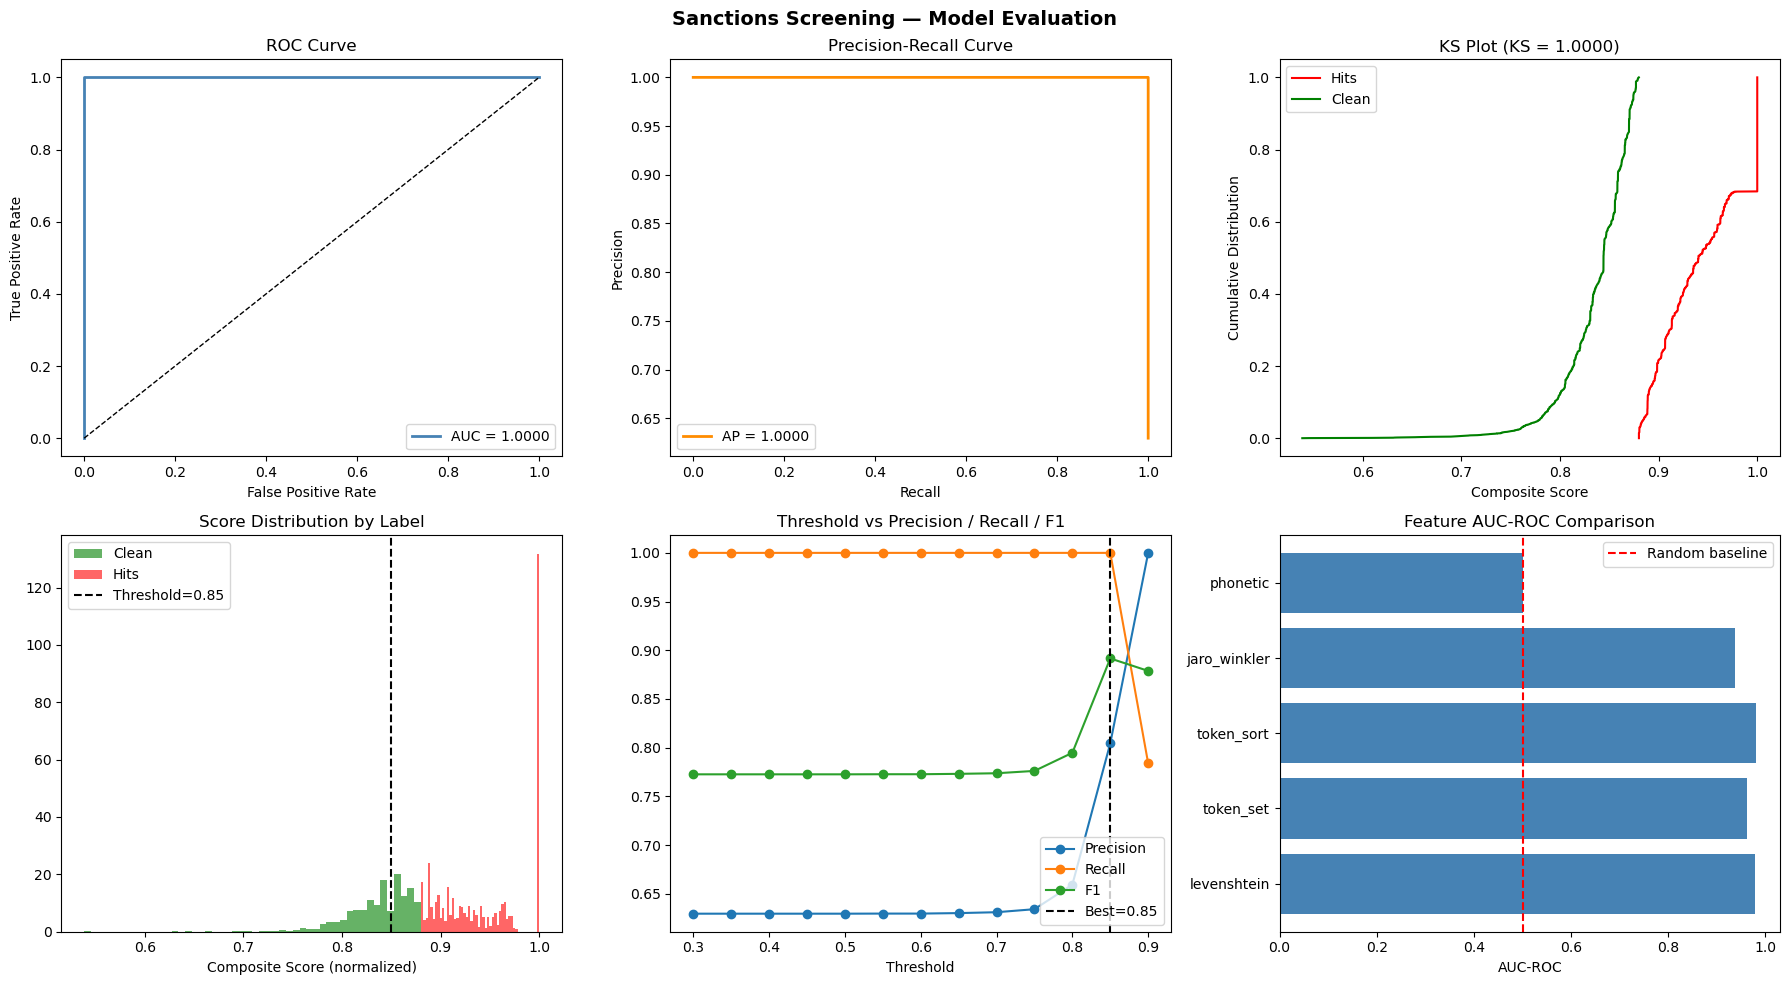

Saved: evaluation_dashboard.png


In [96]:
# ============================================================
# SECTION 7 — Plots
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Sanctions Screening — Model Evaluation", fontsize=14, fontweight="bold")

# 1. ROC Curve
fpr_curve, tpr_curve, _ = roc_curve(y_true, y_score)
axes[0,0].plot(fpr_curve, tpr_curve, color="steelblue", lw=2, label=f"AUC = {auc_roc:.4f}")
axes[0,0].plot([0,1],[0,1], "k--", lw=1)
axes[0,0].set_title("ROC Curve")
axes[0,0].set_xlabel("False Positive Rate")
axes[0,0].set_ylabel("True Positive Rate")
axes[0,0].legend()

# 2. Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_score)
axes[0,1].plot(rec_curve, prec_curve, color="darkorange", lw=2, label=f"AP = {avg_precision:.4f}")
axes[0,1].set_title("Precision-Recall Curve")
axes[0,1].set_xlabel("Recall")
axes[0,1].set_ylabel("Precision")
axes[0,1].legend()

# 3. KS Plot
hits_sorted  = np.sort(hits_scores)
clean_sorted = np.sort(clean_scores)
axes[0,2].plot(hits_sorted,  np.linspace(0,1,len(hits_sorted)),  label="Hits",  color="red")
axes[0,2].plot(clean_sorted, np.linspace(0,1,len(clean_sorted)), label="Clean", color="green")
axes[0,2].set_title(f"KS Plot (KS = {ks_stat:.4f})")
axes[0,2].set_xlabel("Composite Score")
axes[0,2].set_ylabel("Cumulative Distribution")
axes[0,2].legend()

# 4. Score Distribution
axes[1,0].hist(clean_scores, bins=50, alpha=0.6, color="green", label="Clean", density=True)
axes[1,0].hist(hits_scores,  bins=50, alpha=0.6, color="red",   label="Hits",  density=True)
axes[1,0].axvline(best_thresh, color="black", linestyle="--", label=f"Threshold={best_thresh}")
axes[1,0].set_title("Score Distribution by Label")
axes[1,0].set_xlabel("Composite Score (normalized)")
axes[1,0].legend()

# 5. Threshold vs Precision / Recall / F1
axes[1,1].plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", marker="o")
axes[1,1].plot(thresh_df["threshold"], thresh_df["recall"],    label="Recall",    marker="o")
axes[1,1].plot(thresh_df["threshold"], thresh_df["f1"],        label="F1",        marker="o")
axes[1,1].axvline(best_thresh, color="black", linestyle="--", label=f"Best={best_thresh}")
axes[1,1].set_title("Threshold vs Precision / Recall / F1")
axes[1,1].set_xlabel("Threshold")
axes[1,1].legend()

# 6. Feature AUC comparison
axes[1,2].barh(list(feature_aucs.keys()), list(feature_aucs.values()), color="steelblue")
axes[1,2].axvline(0.5, color="red", linestyle="--", label="Random baseline")
axes[1,2].set_title("Feature AUC-ROC Comparison")
axes[1,2].set_xlabel("AUC-ROC")
axes[1,2].legend()

plt.tight_layout()
plt.savefig("evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: evaluation_dashboard.png")

In [34]:
# ============================================================
# SECTION 8 — Summary Report
# ============================================================

print(f"""
{'='*55}
SANCTIONS SCREENING — PERFORMANCE SUMMARY
{'='*55}
Dataset
  Transactions screened:     {len(y_true):,}
  True sanctions hits:       {int(y_true.sum()):,}
  Base hit rate:             {y_true.mean()*100:.2f}%

Discrimination
  AUC-ROC:                   {auc_roc:.4f}
  Gini:                      {gini:.4f}
  AUC-PR:                    {avg_precision:.4f}
  KS Statistic:              {ks_stat:.4f}
  Cohen's d:                 {cohens_d:.4f}

At Optimal Threshold ({best_thresh})
  Precision:                 {best_row['precision']:.4f}
  Recall:                    {best_row['recall']:.4f}
  F1:                        {best_row['f1']:.4f}
  Specificity:               {best_row['specificity']:.4f}
  MCC:                       {mcc:.4f}
  FPR:                       {best_row['fpr']:.4f}
  FNR:                       {best_row['fnr']:.4f}
  Alert Rate:                {best_row['alert_rate']:.2f}%

Calibration
  Brier Score:               {brier:.4f}
  Log Loss:                  {logloss:.4f}
{'='*55}
""")


SANCTIONS SCREENING — PERFORMANCE SUMMARY
Dataset
  Transactions screened:     10,000
  True sanctions hits:       200
  Base hit rate:             2.00%

Discrimination
  AUC-ROC:                   0.6214
  Gini:                      0.2428
  AUC-PR:                    0.0331
  KS Statistic:              0.2818
  Cohen's d:                 0.1187

At Optimal Threshold (0.9)
  Precision:                 0.0315
  Recall:                    0.6950
  F1:                        0.0603
  Specificity:               0.5642
  MCC:                       0.0731
  FPR:                       0.4358
  FNR:                       0.3050
  Alert Rate:                0.44%

Calibration
  Brier Score:               0.7887
  Log Loss:                  8.9515

